# Retinal Vessel Segmentation + Artery/Vein Classifier

Two-stage pipeline:
1. **Binary Segmentation** – MorphoBiFPNUNet: background vs vessel (trained on 8-image subset)
2. **AV Classifier** – Lightweight CNN trained on the **full training set** to label artery vs vein

**Dataset layout** (each split folder):
```
Fundus-AVSeg-prep-data/
  train/    images/, annotation/, npy/
  val/      images/, annotation/, npy/
  test/     images/, annotation/, npy/
```

## Imports

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as T
import math
import cv2
from pathlib import Path
import skimage
from skimage.measure import label, regionprops
import copy, os, time
from collections import Counter

print("All imports successful.")

All imports successful.


## Constants

In [22]:
# ── Binary segmentation constants ─────────────────────────────────────────────
NUM_CLASSES_SEG  = 2          # 0=background, 1=vessel
SEG_CLASS_NAMES  = {0: 'Background', 1: 'Vessel'}
SEG_CLASS_COLORS = {
    0: np.array([  0,   0,   0], dtype=np.uint8),   # Background: black
    1: np.array([255, 255,   0], dtype=np.uint8),   # Vessel:     yellow
}

# ── AV classifier constants ───────────────────────────────────────────────────
AV_CLASS_NAMES   = {1: 'Artery', 2: 'Vein'}        # original label indices
AV_CLASS_COLORS  = {
    1: np.array([255,   0,   0], dtype=np.uint8),   # Artery: red
    2: np.array([  0,   0, 255], dtype=np.uint8),   # Vein:   blue
}

# ── Training subset ───────────────────────────────────────────────────────────
FIXED_INDICES = [1, 3, 5, 6, 7, 12, 15, 16]

print(f"Binary segmentation: {NUM_CLASSES_SEG} classes (background vs vessel)")
print(f"AV classifier: artery vs vein")
print(f"Training subset indices: {FIXED_INDICES}")

Binary segmentation: 2 classes (background vs vessel)
AV classifier: artery vs vein
Training subset indices: [1, 3, 5, 6, 7, 12, 15, 16]


## Dataset Classes

In [23]:
class BinarySegDataset(data.Dataset):
    """
    Binary segmentation dataset: background (0) vs vessel (1).
    Arteries and veins are both mapped to vessel class 1.
    Crossing and Uncertainty pixels are remapped to Background.
    """

    def __init__(self, root, new_size=384, supervised=True):
        self.root       = Path(root)
        self.supervised = supervised
        self.new_size   = new_size
        self.imagesize  = None

        img_dir = self.root / 'images'
        npy_dir = self.root / 'npy'
        ann_dir = self.root / 'annotation'

        self.image_paths         = sorted(img_dir.glob('*.png'))
        self.image_liot_eg_paths = []
        self.label_paths         = []

        for img_path in self.image_paths:
            stem = img_path.stem
            self.image_liot_eg_paths.append(npy_dir / f'{stem}_liot_eg.npy')
            if self.supervised:
                self.label_paths.append(ann_dir / f'{stem}.png')

        print(f"Dataset root     : {root}")
        print(f"  Images found   : {len(self.image_paths)}")

    def borders(self, original_size):
        H, W    = original_size
        delta_h = max(self.new_size - H, 0)
        delta_w = max(self.new_size - W, 0)
        top     = delta_h // 2
        bottom  = delta_h - top
        left    = delta_w // 2
        right   = delta_w - left
        return left, top, right, bottom

    @staticmethod
    def rgb_to_binary_mask(rgb_array):
        """
        Convert RGB annotation to binary mask:
          0 = background (black, green, white)
          1 = vessel     (red artery OR blue vein)
        """
        r, g, b = rgb_array[:, :, 0], rgb_array[:, :, 1], rgb_array[:, :, 2]
        mask    = np.zeros(rgb_array.shape[:2], dtype=np.int64)
        # Artery (red-dominant) → vessel
        mask[(r > 180) & (g < 80)  & (b < 80)]  = 1
        # Vein   (blue-dominant) → vessel
        mask[(r < 80)  & (g < 80)  & (b > 180)] = 1
        return mask

    @staticmethod
    def rgb_to_av_mask(rgb_array):
        """
        Convert RGB annotation to AV class mask:
          0 = background
          1 = artery
          2 = vein
        (Used by classifier dataset to generate AV ground truth.)
        """
        r, g, b = rgb_array[:, :, 0], rgb_array[:, :, 1], rgb_array[:, :, 2]
        mask    = np.zeros(rgb_array.shape[:2], dtype=np.int64)
        mask[(r > 180) & (g < 80)  & (b < 80)]  = 1  # artery
        mask[(r < 80)  & (g < 80)  & (b > 180)] = 2  # vein
        return mask

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert('RGB')
        self.imagesize        = np.array(image).shape[:2]
        left, top, right, bottom = self.borders(self.imagesize)
        pad   = (left, top, right, bottom)

        img_tf = T.Compose([T.ToTensor(), T.Pad(pad)])
        image  = img_tf(image)

        liot = np.load(self.image_liot_eg_paths[index])
        liot = img_tf(liot.transpose(1, 2, 0))

        if self.supervised:
            ann_rgb   = np.array(Image.open(self.label_paths[index]).convert('RGB'))
            bin_mask  = self.rgb_to_binary_mask(ann_rgb)
            av_mask   = self.rgb_to_av_mask(ann_rgb)
            bin_mask  = np.pad(bin_mask, ((top, bottom), (left, right)), constant_values=0)
            av_mask   = np.pad(av_mask,  ((top, bottom), (left, right)), constant_values=0)
            bin_label = torch.from_numpy(bin_mask)
            av_label  = torch.from_numpy(av_mask)
            return image, liot, bin_label, av_label

        return image, liot

## Load Data

In [24]:
root = r"/home/mefeki/Bureau/work/Fundus-AVSeg-prep-data"   # ← update if needed

# new_size=384 reduces spatial resolution to fit in GPU memory (down from 592)
IMG_SIZE = 384
train_dataset_full = BinarySegDataset(root=os.path.join(root, 'train'), new_size=IMG_SIZE)
val_dataset        = BinarySegDataset(root=os.path.join(root, 'val'),   new_size=IMG_SIZE)
test_dataset       = BinarySegDataset(root=os.path.join(root, 'test'),  new_size=IMG_SIZE)

val_dataloader  = data.DataLoader(val_dataset,  shuffle=False, batch_size=1)
test_dataloader = data.DataLoader(test_dataset, shuffle=False, batch_size=1)

print(f"Train (full): {len(train_dataset_full)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Dataset root     : /home/mefeki/Bureau/work/Fundus-AVSeg-prep-data/train
  Images found   : 70
Dataset root     : /home/mefeki/Bureau/work/Fundus-AVSeg-prep-data/val
  Images found   : 10
Dataset root     : /home/mefeki/Bureau/work/Fundus-AVSeg-prep-data/test
  Images found   : 20
Train (full): 70 | Val: 10 | Test: 20


## Utilities

In [25]:
def bin_mask_to_rgb(mask_np):
    """Convert binary (H,W) int mask → RGB (H,W,3)."""
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for cls_idx, color in SEG_CLASS_COLORS.items():
        rgb[mask_np == cls_idx] = color
    return rgb


def av_mask_to_rgb(mask_np):
    """Convert AV (H,W) mask (0=bg,1=artery,2=vein) → RGB (H,W,3)."""
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    rgb[mask_np == 1] = AV_CLASS_COLORS[1]   # artery: red
    rgb[mask_np == 2] = AV_CLASS_COLORS[2]   # vein:   blue
    return rgb


def remove_circle(inputs, preds, kernel_size=7, threshold=0.1):
    """Zero-out predictions outside the circular FOV."""
    if inputs.shape[1] == 4:
        rgb   = inputs[:, :3]
        alpha = inputs[:, 3:]
        inputs = rgb * alpha + (1 - alpha)
    gray = T.Grayscale()(inputs)
    mask = (gray > threshold).float()
    p1 = -F.max_pool2d(-mask, (kernel_size, 1), stride=1, padding=(kernel_size // 2, 0))
    p2 = -F.max_pool2d(-mask, (1, kernel_size), stride=1, padding=(0, kernel_size // 2))
    circle = (torch.min(p1, p2) > 0).squeeze(1).long()
    return preds * circle


def dice_binary(preds, labels, eps=1e-6):
    """Dice for vessel class (class 1)."""
    p = (preds == 1).float()
    l = (labels == 1).float()
    tp = float(torch.sum(p * l))
    fp = float(torch.sum(p * (1 - l)))
    fn = float(torch.sum((1 - p) * l))
    return 2 * tp / (2 * tp + fp + fn + eps)


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


## Network Architecture: MorphoBiFPNUNet (Binary)

In [26]:
# ── Shared building blocks ──────────────────────────────────────────────────

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)


class MorphoLayer(nn.Module):
    """
    Learnable morphological pre-processing:
      dilation = max_pool2d(x, k)
      erosion  = -max_pool2d(-x, k)
    Concatenate both -> project back to in_ch via 1x1 conv.
    """
    def __init__(self, in_ch, kernel_size=7):
        super().__init__()
        self.k    = kernel_size
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch * 2, in_ch, 1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        pad      = self.k // 2
        dilation = F.max_pool2d(x,  self.k, stride=1, padding=pad)
        erosion  = -F.max_pool2d(-x, self.k, stride=1, padding=pad)
        return self.proj(torch.cat([dilation, erosion], dim=1))


class Encoder(nn.Module):
    def __init__(self, in_ch=10, base_ch=64, depth=4):
        super().__init__()
        chs = [base_ch * (2 ** i) for i in range(depth)]
        self.blocks = nn.ModuleList()
        self.pools  = nn.ModuleList()
        in_c = in_ch
        for c in chs:
            self.blocks.append(ConvBlock(in_c, c))
            self.pools.append(nn.MaxPool2d(2))
            in_c = c
        self.out_channels = chs

    def forward(self, x):
        feats = []
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            feats.append(x)
            x = pool(x)
        return feats


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))


class BiFPN(nn.Module):
    """
    Bidirectional FPN with fast-normalised fusion.

    Fix: all encoder levels are projected to a uniform feat_ch via lateral
    1x1 convs BEFORE weighted fusion, so tensors of different channel widths
    (e.g. 64, 128, 256, 512) are never added together directly.
    """
    def __init__(self, channels, feat_ch=256, num_layers=2, eps=1e-4):
        super().__init__()
        self.eps        = eps
        self.feat_ch    = feat_ch
        self.num_levels = len(channels)
        self.num_layers = num_layers

        # Project every encoder level to feat_ch
        self.laterals = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(c, feat_ch, 1, bias=False),
                nn.BatchNorm2d(feat_ch),
                nn.ReLU(inplace=True),
            ) for c in channels
        ])

        # All fusion convs now operate at the same feat_ch
        self.convs_td = nn.ModuleList([ConvBlock(feat_ch, feat_ch) for _ in channels])
        self.convs_bu = nn.ModuleList([ConvBlock(feat_ch, feat_ch) for _ in channels])
        self.w_td     = nn.Parameter(torch.ones(num_layers, self.num_levels, 2))
        self.w_bu     = nn.Parameter(torch.ones(num_layers, self.num_levels, 3))

    def _resize(self, src, tgt):
        if src.shape[-2:] != tgt.shape[-2:]:
            return F.interpolate(src, size=tgt.shape[-2:], mode='bilinear', align_corners=False)
        return src

    def forward(self, feats):
        # Project all levels to feat_ch first
        P = [lat(f) for lat, f in zip(self.laterals, feats)]

        for l in range(self.num_layers):
            td = [None] * self.num_levels
            td[-1] = P[-1]
            w_td   = F.relu(self.w_td[l])
            w_td   = w_td / (w_td.sum(-1, keepdim=True) + self.eps)
            for i in range(self.num_levels - 2, -1, -1):
                fused = w_td[i, 0] * P[i] + w_td[i, 1] * self._resize(td[i + 1], P[i])
                td[i] = self.convs_td[i](fused)

            bu = [None] * self.num_levels
            bu[0] = td[0]
            w_bu  = F.relu(self.w_bu[l])
            w_bu  = w_bu / (w_bu.sum(-1, keepdim=True) + self.eps)
            for i in range(1, self.num_levels):
                fused = (w_bu[i, 0] * P[i] +
                         w_bu[i, 1] * td[i] +
                         w_bu[i, 2] * self._resize(bu[i - 1], P[i]))
                bu[i] = self.convs_bu[i](fused)
            P = bu
        return P


class MorphoBiFPNUNet(nn.Module):
    """
    MorphoBiFPNUNet for binary segmentation (background vs vessel).
    The decoder uses feat_ch (BiFPN output width) as its skip channel size.
    """
    def __init__(self, in_channels=10, num_classes=2, base_ch=64,
                 depth=4, bifpn_layers=2, morpho_kernel=7, bifpn_feat_ch=256):
        super().__init__()
        self.morpho     = MorphoLayer(in_channels, kernel_size=morpho_kernel)
        self.encoder    = Encoder(in_ch=in_channels, base_ch=base_ch, depth=depth)
        enc_chs         = self.encoder.out_channels          # e.g. [64,128,256,512]
        self.bifpn      = BiFPN(channels=enc_chs, feat_ch=bifpn_feat_ch, num_layers=bifpn_layers)
        self.bottleneck = ConvBlock(bifpn_feat_ch, bifpn_feat_ch)

        # Decoder: every level now has bifpn_feat_ch channels after BiFPN
        self.up_blocks = nn.ModuleList()
        in_c = bifpn_feat_ch
        for _ in range(depth - 1):
            self.up_blocks.append(UpBlock(in_c, bifpn_feat_ch, bifpn_feat_ch))
            in_c = bifpn_feat_ch
        self.final_conv = nn.Conv2d(in_c, num_classes, 1)

    def forward(self, x):
        x     = self.morpho(x)
        feats = self.encoder(x)
        fused = self.bifpn(feats)          # all levels now bifpn_feat_ch wide
        x     = self.bottleneck(fused[-1])
        for i, up in enumerate(self.up_blocks):
            x = up(x, fused[-2 - i])
        return self.final_conv(x)


print('MorphoBiFPNUNet (binary, fixed BiFPN) defined.')


MorphoBiFPNUNet (binary, fixed BiFPN) defined.


## Loss & Training / Validation Functions

In [27]:
class WeightedCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, outputs, labels):
        return self.criterion(outputs, labels.long())


def train_seg_model(model, criterion, optimizer, dataloader, num_epochs, val_loader=None):
    """Train binary segmentation model; validate each epoch on val_loader."""
    train_losses = []
    val_dices    = []

    for epoch in range(num_epochs):
        model.train()
        batch_losses = []

        for inputs, liot, bin_lbl, _ in dataloader:
            liot    = liot.to(device)
            bin_lbl = bin_lbl.to(device)

            optimizer.zero_grad()
            logits = model(liot)
            loss   = criterion(logits, bin_lbl)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        mean_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(mean_loss)

        val_dice = 0.0
        if val_loader is not None:
            model.eval()
            with torch.no_grad():
                dices = []
                for img, liot_v, bin_lbl, _ in val_loader:
                    img     = img.to(device)
                    liot_v  = liot_v.to(device)
                    bin_lbl = bin_lbl.to(device)
                    logits  = model(liot_v)
                    preds   = torch.argmax(torch.softmax(logits, dim=1), dim=1)
                    preds   = remove_circle(img, preds)
                    dices.append(dice_binary(preds, bin_lbl))
                val_dice = float(np.mean(dices))
            val_dices.append(val_dice)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | Loss: {mean_loss:.4f}"
                  + (f" | Val Dice: {val_dice:.4f}" if val_loader else ""))

    print("Training complete.")
    return model, train_losses, val_dices


print("Loss and training functions defined.")

Loss and training functions defined.


## Train Binary Segmentation Model (8-image subset)

In [10]:
import gc
gc.collect()
torch.cuda.empty_cache()

# ── Fixed 8-image subset ──────────────────────────────────────────────────────
assert all(i < len(train_dataset_full) for i in FIXED_INDICES), \
    f"Index out of range (max={len(train_dataset_full)-1})"

subset_dataset    = torch.utils.data.Subset(train_dataset_full, FIXED_INDICES)
subset_dataloader = data.DataLoader(subset_dataset, shuffle=True, batch_size=1)

print(f"Training on {len(subset_dataset)} images (indices {FIXED_INDICES})")
print(f"Validation on {len(val_dataset)} images")

# ── Class weights from subset ─────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

pixel_counts = Counter()
for _, _, bin_lbl, _ in subset_dataset:
    for c in range(NUM_CLASSES_SEG):
        pixel_counts[c] += int((bin_lbl == c).sum())

total    = sum(pixel_counts.values())
freqs    = torch.tensor([pixel_counts[c] / total for c in range(NUM_CLASSES_SEG)])
inv_freq = 1.0 / (freqs + 1e-6)
class_weights = (inv_freq / inv_freq.mean()).to(device)

print(f"Class pixel %: background={100*freqs[0]:.2f}%, vessel={100*freqs[1]:.2f}%")
print(f"Class weights: {class_weights.tolist()}")

# ── Model, loss, optimiser ────────────────────────────────────────────────────
EPOCHS = 150

# bifpn_feat_ch=128 keeps memory usage low; increase if GPU memory allows
seg_model = MorphoBiFPNUNet(
    in_channels=10, num_classes=NUM_CLASSES_SEG, morpho_kernel=7, bifpn_feat_ch=32
).to(device)

seg_criterion = WeightedCELoss(class_weights=class_weights)
seg_optimizer = optim.Adam(seg_model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-7)

seg_model, train_losses, val_dices = train_seg_model(
    seg_model, seg_criterion, seg_optimizer,
    subset_dataloader, EPOCHS, val_loader=val_dataloader
)

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
torch.save(seg_model.state_dict(), 'models/seg_model_binary.pth')
print("Segmentation model saved to models/seg_model_binary.pth")

Training on 8 images (indices [1, 3, 5, 6, 7, 12, 15, 16])
Validation on 10 images
Class pixel %: background=91.23%, vessel=8.77%
Class weights: [0.17536695301532745, 1.8246331214904785]
Epoch   1/150 | Loss: 0.5504 | Val Dice: 0.0000
Epoch  10/150 | Loss: 0.2140 | Val Dice: 0.7023
Epoch  20/150 | Loss: 0.1423 | Val Dice: 0.7704
Epoch  30/150 | Loss: 0.1192 | Val Dice: 0.7612
Epoch  40/150 | Loss: 0.0988 | Val Dice: 0.7790
Epoch  50/150 | Loss: 0.0841 | Val Dice: 0.8235
Epoch  60/150 | Loss: 0.0773 | Val Dice: 0.7941
Epoch  70/150 | Loss: 0.0651 | Val Dice: 0.8180
Epoch  80/150 | Loss: 0.0541 | Val Dice: 0.8051
Epoch  90/150 | Loss: 0.0601 | Val Dice: 0.8263
Epoch 100/150 | Loss: 0.0449 | Val Dice: 0.8422
Epoch 110/150 | Loss: 0.0461 | Val Dice: 0.7932
Epoch 120/150 | Loss: 0.0410 | Val Dice: 0.8355
Epoch 130/150 | Loss: 0.0588 | Val Dice: 0.8152
Epoch 140/150 | Loss: 0.0337 | Val Dice: 0.8547
Epoch 150/150 | Loss: 0.0364 | Val Dice: 0.8412
Training complete.
Segmentation model saved t

## Segmentation Training Curves

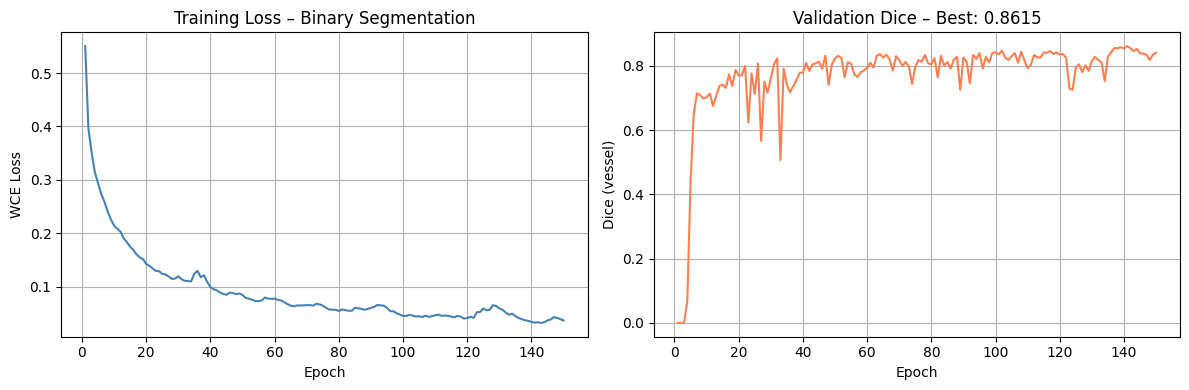

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), train_losses, color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('WCE Loss')
axes[0].set_title('Training Loss – Binary Segmentation')
axes[0].grid(True)

if val_dices:
    axes[1].plot(range(1, EPOCHS + 1), val_dices, color='coral')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice (vessel)')
    axes[1].set_title(f'Validation Dice – Best: {max(val_dices):.4f}')
    axes[1].grid(True)

plt.tight_layout()
plt.savefig('seg_training_curves.png', dpi=150)
plt.show()

## Vessel Tree Graph – AV Classifier (Graph-Based)

Instead of a pixel-wise FCN, we:
1. **Skeletonise** the binary vessel mask → 1-pixel-wide skeleton.
2. **Build a graph** where **nodes** are bifurcation/endpoint pixels and **edges** are vessel segments.
3. **Extract per-edge features**: mean intensity (green channel), estimated width, length, degree of end-nodes.
4. **Train a Random-Forest** on those features to label each edge as *artery* (1) or *vein* (2).
5. **Paint the mask** back: each vessel pixel is assigned the label of the skeleton edge nearest to it.


In [ ]:
import networkx as nx
from skimage.morphology import skeletonize
from skimage.measure import label as sk_label
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
print("Graph-based AV classifier imports OK.")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Vessel Tree Graph utilities
# ═══════════════════════════════════════════════════════════════════════════════

def build_vessel_graph(binary_mask_np):
    """
    Convert a binary vessel mask to an undirected NetworkX graph.

    Nodes  : bifurcation pixels (≥3 skeleton neighbours) + endpoints (1 neighbour)
    Edges  : paths along the skeleton connecting two nodes (stored as pixel lists)

    Returns
    -------
    G        : nx.Graph  (each edge has attribute 'pixels': list of (r,c) tuples)
    skel     : (H,W) bool skeleton array
    """
    skel = skeletonize(binary_mask_np > 0)
    H, W = skel.shape

    # 8-connectivity neighbour count for every skeleton pixel
    def neighbours(r, c):
        pts = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < H and 0 <= nc < W and skel[nr, nc]:
                    pts.append((nr, nc))
        return pts

    skel_pts   = list(zip(*np.where(skel)))
    deg        = {p: len(neighbours(*p)) for p in skel_pts}

    # Junction nodes: degree ≥ 3  |  endpoint nodes: degree == 1
    node_set   = {p for p, d in deg.items() if d >= 3 or d == 1}

    G = nx.Graph()
    G.add_nodes_from(node_set)

    visited_edges = set()

    for start in node_set:
        for nb in neighbours(*start):
            if (start, nb) in visited_edges or (nb, start) in visited_edges:
                continue
            # Trace the segment from start through nb until we hit another node
            path   = [start, nb]
            prev, cur = start, nb
            while cur not in node_set:
                nbs = [n for n in neighbours(*cur) if n != prev]
                if not nbs:
                    break
                prev, cur = cur, nbs[0]
                path.append(cur)
            if cur in node_set and cur != start:
                e = (start, cur)
                if e not in visited_edges and (e[1], e[0]) not in visited_edges:
                    visited_edges.add(e)
                    G.add_edge(start, cur, pixels=path)

    return G, skel


def extract_edge_features(G, rgb_np, binary_mask_np):
    """
    For each edge in G compute:
      - mean green-channel intensity along the edge pixels
      - estimated vessel width (ratio of mask pixels in a bounding strip)
      - segment length (number of skeleton pixels)
      - mean degree of the two endpoint nodes
      - tortuosity (euclidean / arc length ratio)

    Returns
    -------
    edges_list : list of (u, v) in G order
    X          : (N, 5) float array of features
    """
    green = rgb_np[:, :, 1].astype(np.float32) / 255.0
    H, W  = binary_mask_np.shape
    edges_list, rows = [], []

    for u, v, data_e in G.edges(data=True):
        pixels = data_e.get('pixels', [u, v])
        rs     = np.array([p[0] for p in pixels])
        cs     = np.array([p[1] for p in pixels])

        # Mean intensity
        mean_int = float(green[rs, cs].mean())

        # Width estimate: average local width via distance transform
        from scipy.ndimage import distance_transform_edt
        dist = distance_transform_edt(binary_mask_np > 0)
        mean_w = float(dist[rs, cs].mean() * 2)

        # Length
        length = len(pixels)

        # Mean endpoint degree
        deg_u = G.degree(u)
        deg_v = G.degree(v)
        mean_deg = (deg_u + deg_v) / 2.0

        # Tortuosity
        euc = np.sqrt((rs[-1] - rs[0])**2 + (cs[-1] - cs[0])**2) + 1e-6
        tort = length / euc

        edges_list.append((u, v))
        rows.append([mean_int, mean_w, length, mean_deg, tort])

    X = np.array(rows, dtype=np.float32) if rows else np.zeros((0, 5), dtype=np.float32)
    return edges_list, X


def edge_labels_from_av_gt(G, edges_list, av_mask_np):
    """
    Vote on AV label for each edge using the ground-truth AV mask.
    Majority vote over all skeleton pixels in the edge.
    Returns y: int array (1=artery, 2=vein), and valid_mask (edges that touch GT).
    """
    y, valid = [], []
    for u, v in edges_list:
        data_e = G[u][v]
        pixels = data_e.get('pixels', [u, v])
        labels = [av_mask_np[p[0], p[1]] for p in pixels if av_mask_np[p[0], p[1]] > 0]
        if labels:
            from collections import Counter
            vote = Counter(labels).most_common(1)[0][0]
            y.append(vote)
            valid.append(True)
        else:
            y.append(0)   # background – will be excluded from training
            valid.append(False)
    return np.array(y, dtype=np.int64), np.array(valid)


def paint_av_mask(G, edges_list, edge_preds, binary_mask_np, skel):
    """
    Assign each vessel pixel the label of its nearest skeleton edge.
    edge_preds: 1=artery, 2=vein (per edge, same order as edges_list).
    """
    H, W   = binary_mask_np.shape
    av_out = np.zeros((H, W), dtype=np.int64)

    # Build a pixel→edge_label lookup from skeleton pixels
    pix_label = {}
    for (u, v), pred in zip(edges_list, edge_preds):
        data_e = G[u][v]
        for p in data_e.get('pixels', [u, v]):
            pix_label[p] = pred

    # For non-skeleton vessel pixels: use nearest skeleton pixel label via
    # scipy distance transform index map
    from scipy.ndimage import distance_transform_edt
    skel_bool = skel.astype(bool)
    _, idx    = distance_transform_edt(~skel_bool, return_indices=True)

    vessel_pts = np.where(binary_mask_np > 0)
    for r, c in zip(*vessel_pts):
        nr, nc = idx[0, r, c], idx[1, r, c]
        av_out[r, c] = pix_label.get((nr, nc), 0)

    return av_out


print("Graph utilities defined.")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Build graph feature dataset from the full training set
# ═══════════════════════════════════════════════════════════════════════════════

def build_graph_dataset(seg_dataset):
    """
    Iterate over a BinarySegDataset, build vessel graphs, extract features.

    Returns
    -------
    X_all : (N_edges_total, 5) float
    y_all : (N_edges_total,)  int  — 1=artery, 2=vein  (0-labelled edges excluded)
    """
    X_parts, y_parts = [], []

    for idx in range(len(seg_dataset)):
        img_t, _, bin_lbl, av_lbl = seg_dataset[idx]
        rgb_np   = img_t.permute(1, 2, 0).clamp(0, 1).numpy()
        bin_np   = bin_lbl.numpy().astype(np.uint8)
        av_np    = av_lbl.numpy()

        if bin_np.sum() == 0:
            continue

        G, skel = build_vessel_graph(bin_np)
        if G.number_of_edges() == 0:
            continue

        edges_list, X = extract_edge_features(G, rgb_np, bin_np)
        if X.shape[0] == 0:
            continue

        y, valid = edge_labels_from_av_gt(G, edges_list, av_np)

        # Keep only edges with a GT label
        mask = valid & (y > 0)
        if mask.sum() == 0:
            continue

        X_parts.append(X[mask])
        y_parts.append(y[mask])

    if not X_parts:
        return np.zeros((0, 5)), np.zeros(0, dtype=np.int64)

    return np.concatenate(X_parts), np.concatenate(y_parts)


print("Building graph feature dataset from training set…")
X_train_g, y_train_g = build_graph_dataset(train_dataset_full)
print(f"  Edges collected: {len(X_train_g)}")
print(f"  Artery edges  : {(y_train_g == 1).sum()}")
print(f"  Vein edges    : {(y_train_g == 2).sum()}")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Train Random Forest on edge features
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_g, y_train_g)

# Quick training accuracy
train_acc = accuracy_score(y_train_g, rf_model.predict(X_train_g))
print(f"Random Forest trained.  Training accuracy on edge labels: {train_acc:.4f}")

feat_names = ['mean_green_intensity', 'mean_width', 'length', 'mean_degree', 'tortuosity']
importances = rf_model.feature_importances_
print("\nFeature importances:")
for n, imp in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f"  {n:30s}: {imp:.4f}")


## Two-Stage Inference Pipeline (Graph-Based)

```
LIOT  →  MorphoBiFPNUNet  →  binary_mask
binary_mask + RGB  →  VesselGraph  →  RandomForest  →  artery/vein map
```

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Graph-based run_pipeline (replaces FCN pipeline)
# ═══════════════════════════════════════════════════════════════════════════════

def run_graph_pipeline(seg_model, rf_clf, img_t, liot_t):
    """
    Two-stage inference using the graph-based AV classifier.

    Parameters
    ----------
    seg_model : MorphoBiFPNUNet  (binary segmentation)
    rf_clf    : fitted RandomForestClassifier
    img_t     : (1,3,H,W) float tensor
    liot_t    : (1,10,H,W) float tensor

    Returns
    -------
    bin_pred  : (H,W) LongTensor – 0=bg, 1=vessel
    av_pred   : (H,W) ndarray int64 – 0=bg, 1=artery, 2=vein
    """
    seg_model.eval()
    with torch.no_grad():
        logits   = seg_model(liot_t)
        bin_pred = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (1,H,W)
        bin_pred = remove_circle(img_t, bin_pred)

    bin_np  = bin_pred[0].cpu().numpy().astype(np.uint8)
    rgb_np  = img_t[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy()

    if bin_np.sum() == 0:
        av_out = np.zeros_like(bin_np, dtype=np.int64)
        return bin_pred[0].cpu(), av_out

    G, skel = build_vessel_graph(bin_np)
    if G.number_of_edges() == 0:
        av_out = np.zeros_like(bin_np, dtype=np.int64)
        return bin_pred[0].cpu(), av_out

    edges_list, X = extract_edge_features(G, rgb_np, bin_np)
    if X.shape[0] == 0:
        av_out = np.zeros_like(bin_np, dtype=np.int64)
        return bin_pred[0].cpu(), av_out

    edge_preds = rf_clf.predict(X)                   # 1=artery, 2=vein per edge
    av_out     = paint_av_mask(G, edges_list, edge_preds, bin_np, skel)

    return bin_pred[0].cpu(), av_out


print("Graph pipeline function defined.")


In [34]:
# 1. Instantiate and load Binary Segmentation Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Try using base_ch=32, which seems to match the checkpoint's parameter size
seg_model = MorphoBiFPNUNet(
    in_channels=10, 
    num_classes=2, 
    base_ch=32,        # Changed from 64 to 32 based on the mismatch logs
    depth=4, 
    bifpn_layers=2, 
    morpho_kernel=7, 
    bifpn_feat_ch=32   # Changed from 256 to 32 based on the mismatch logs
).to(device)

# Now load the state dict
seg_model.load_state_dict(torch.load('/home/mefeki/Bureau/work/multi_step_back/models/seg_model_binary.pth', map_location=device))
seg_model.eval()

print("Segmentation model loaded successfully.")

# 3. Now you can safely call the pipeline
# Example: bin_pred, av_pred = run_pipeline(seg_model, av_model, img_t, liot_t)

RuntimeError: Error(s) in loading state_dict for MorphoBiFPNUNet:
	size mismatch for encoder.blocks.0.conv.0.weight: copying a param with shape torch.Size([64, 10, 3, 3]) from checkpoint, the shape in current model is torch.Size([32, 10, 3, 3]).
	size mismatch for encoder.blocks.0.conv.1.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for encoder.blocks.0.conv.1.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for encoder.blocks.0.conv.1.running_mean: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for encoder.blocks.0.conv.1.running_var: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for encoder.blocks.0.conv.3.weight: copying a param with shape torch.Size([64, 64, 3, 3]) 

## Metrics: DSC and IoU

Two new metrics are added for the **AV classification** stage:
- **DSC (Dice Similarity Coefficient)** per class and mean
- **IoU (Intersection over Union)** per class and mean

Computed over **vessel pixels only** (background excluded).


In [ ]:
def dsc_iou_av(av_pred_np, av_gt_np, bin_gt_np):
    """
    Compute per-class DSC and IoU for artery (1) and vein (2).
    Only vessel pixels (bin_gt_np==1) are considered.

    Returns dicts: {1: score_artery, 2: score_vein}
    """
    vessel = (bin_gt_np == 1)
    dsc, iou = {}, {}

    for cls in [1, 2]:
        pred_c = (av_pred_np == cls) & vessel
        gt_c   = (av_gt_np   == cls) & vessel

        tp = float((pred_c & gt_c).sum())
        fp = float((pred_c & ~gt_c).sum())
        fn = float((~pred_c & gt_c).sum())

        dsc[cls] = (2 * tp) / (2 * tp + fp + fn + 1e-6)
        iou[cls] = tp / (tp + fp + fn + 1e-6)

    return dsc, iou


print("DSC / IoU metric functions defined.")


## Evaluate Full Pipeline on Test Set

In [ ]:
def evaluate_graph_pipeline(seg_model, rf_clf, test_ds, n_display=4):
    """
    Evaluate the graph-based pipeline on the test set.
    Reports:
      - Binary vessel Dice
      - AV pixel accuracy, per-class artery / vein accuracy
      - AV DSC (mean, artery, vein)
      - AV IoU (mean, artery, vein)
    """
    seg_dices   = []
    av_accs     = []
    artery_accs = []
    vein_accs   = []
    dsc_arts    = []
    dsc_veins   = []
    iou_arts    = []
    iou_veins   = []

    indices     = list(range(len(test_ds)))
    display_idx = random.sample(indices, min(n_display, len(indices)))
    all_results = []

    for i in range(len(test_ds)):
        img_t, liot_t, bin_gt, av_gt = test_ds[i]
        img_t  = img_t.unsqueeze(0).to(device)
        liot_t = liot_t.unsqueeze(0).to(device)
        bin_gt_np = bin_gt.numpy()
        av_gt_np  = av_gt.numpy()

        bin_pred_t, av_pred_np = run_graph_pipeline(seg_model, rf_clf, img_t, liot_t)
        bin_pred_np = bin_pred_t.numpy()

        # ── Segmentation Dice ────────────────────────────────────────────────
        seg_dices.append(dice_binary(
            torch.from_numpy(bin_pred_np), torch.from_numpy(bin_gt_np)
        ))

        # ── AV metrics (only where GT has vessel) ────────────────────────────
        vessel_mask = (bin_gt_np == 1)
        if vessel_mask.sum() > 0:
            # Pixel accuracy
            av_correct = ((av_pred_np == av_gt_np) & vessel_mask).sum()
            av_accs.append(av_correct / vessel_mask.sum())

            art_mask = (av_gt_np == 1)
            vei_mask = (av_gt_np == 2)
            if art_mask.sum() > 0:
                artery_accs.append(
                    ((av_pred_np == 1) & art_mask).sum() / art_mask.sum()
                )
            if vei_mask.sum() > 0:
                vein_accs.append(
                    ((av_pred_np == 2) & vei_mask).sum() / vei_mask.sum()
                )

            # DSC & IoU
            dsc, iou = dsc_iou_av(av_pred_np, av_gt_np, bin_gt_np)
            dsc_arts.append(dsc[1]);   dsc_veins.append(dsc[2])
            iou_arts.append(iou[1]);   iou_veins.append(iou[2])

        all_results.append((i, img_t.cpu(), bin_pred_np, av_pred_np,
                            bin_gt_np, av_gt_np,
                            seg_dices[-1], av_accs[-1] if av_accs else 0))

    print("\n=== Test Set Evaluation – Graph-Based AV Classifier ===")
    print(f"Binary Vessel Dice        : {np.mean(seg_dices):.4f} ± {np.std(seg_dices):.4f}")
    print(f"AV Pixel Accuracy         : {np.mean(av_accs):.4f} ± {np.std(av_accs):.4f}")
    print(f"  Artery pixel accuracy   : {np.mean(artery_accs):.4f}")
    print(f"  Vein   pixel accuracy   : {np.mean(vein_accs):.4f}")
    print(f"AV DSC  (mean)            : {(np.mean(dsc_arts)+np.mean(dsc_veins))/2:.4f}")
    print(f"  Artery DSC              : {np.mean(dsc_arts):.4f}")
    print(f"  Vein   DSC              : {np.mean(dsc_veins):.4f}")
    print(f"AV IoU  (mean)            : {(np.mean(iou_arts)+np.mean(iou_veins))/2:.4f}")
    print(f"  Artery IoU              : {np.mean(iou_arts):.4f}")
    print(f"  Vein   IoU              : {np.mean(iou_veins):.4f}")

    # ── Visualise n_display examples ─────────────────────────────────────────
    print(f"\nShowing {len(display_idx)} test examples…")
    for i in display_idx:
        _, img_t, bin_pred_np, av_pred_np, bin_gt_np, av_gt_np, d, acc = all_results[i]
        img_np       = img_t[0].permute(1, 2, 0).clamp(0, 1).numpy()
        bin_pred_rgb = bin_mask_to_rgb(bin_pred_np)
        bin_gt_rgb   = bin_mask_to_rgb(bin_gt_np)
        av_pred_rgb  = av_mask_to_rgb(av_pred_np)
        av_gt_rgb    = av_mask_to_rgb(av_gt_np)

        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        axes[0].imshow(img_np);        axes[0].set_title('Fundus Image')
        axes[1].imshow(bin_gt_rgb);    axes[1].set_title('Vessel GT')
        axes[2].imshow(bin_pred_rgb);  axes[2].set_title(f'Vessel Pred  Dice={d:.3f}')
        axes[3].imshow(av_gt_rgb);     axes[3].set_title('AV Ground Truth')
        axes[4].imshow(av_pred_rgb);   axes[4].set_title(f'AV Pred (Graph)  Acc={acc:.3f}')
        for ax in axes: ax.axis('off')
        legend = [
            mpatches.Patch(color=[1, 0, 0], label='Artery'),
            mpatches.Patch(color=[0, 0, 1], label='Vein'),
        ]
        axes[4].legend(handles=legend, loc='lower right', fontsize=8)
        fig.suptitle(f"Test image #{i}", fontsize=12)
        fig.tight_layout()
        plt.savefig(f'test_result_graph_{i}.png', dpi=150)
        plt.show()

    return seg_dices, av_accs, dsc_arts, dsc_veins, iou_arts, iou_veins


seg_dices, av_accs, dsc_arts, dsc_veins, iou_arts, iou_veins = evaluate_graph_pipeline(
    seg_model, rf_model, test_dataset, n_display=4
)


## Summary Table

In [ ]:
summary = pd.DataFrame({
    'Test Image': [f'#{i}' for i in range(len(seg_dices))],
    'Vessel Dice': [f'{d:.4f}' for d in seg_dices],
    'AV Pixel Acc': [f'{a:.4f}' for a in av_accs] + [''] * (len(seg_dices) - len(av_accs)),
    'Artery DSC':   [f'{d:.4f}' for d in dsc_arts] + [''] * (len(seg_dices) - len(dsc_arts)),
    'Vein DSC':     [f'{d:.4f}' for d in dsc_veins] + [''] * (len(seg_dices) - len(dsc_veins)),
    'Artery IoU':   [f'{d:.4f}' for d in iou_arts] + [''] * (len(seg_dices) - len(iou_arts)),
    'Vein IoU':     [f'{d:.4f}' for d in iou_veins] + [''] * (len(seg_dices) - len(iou_veins)),
})
# Append mean row
means = {
    'Test Image':  'Mean',
    'Vessel Dice': f'{np.mean(seg_dices):.4f}',
    'AV Pixel Acc': f'{np.mean(av_accs):.4f}' if av_accs else 'N/A',
    'Artery DSC':  f'{np.mean(dsc_arts):.4f}' if dsc_arts else 'N/A',
    'Vein DSC':    f'{np.mean(dsc_veins):.4f}' if dsc_veins else 'N/A',
    'Artery IoU':  f'{np.mean(iou_arts):.4f}' if iou_arts else 'N/A',
    'Vein IoU':    f'{np.mean(iou_veins):.4f}' if iou_veins else 'N/A',
}
summary = pd.concat([summary, pd.DataFrame([means])], ignore_index=True)
print(summary.to_string(index=False))
